In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
from scipy.interpolate import griddata
from scipy.spatial import cKDTree
from matplotlib.colors import to_rgb

import sys
sys.path.append('/home/z5297792/UNSW-MRes/MRes/SEACOFS_dataset') 
from clim_functions import compute_core_mean


In [2]:
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_eddies_processed.pkl')
df_tilt = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_tilt.pkl')
df_eddies = df_eddies.merge(
    df_tilt[['Eddy', 'Day', 'TiltDis', 'TiltDir']],
    how='left',
    left_on=['Eddy', 'Day'],
    right_on=['Eddy', 'Day']
)
df_eddies



,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,q22,Rc,psi0,AR,R,Age,Date,fname,TiltDis,TiltDir
0,1,1462,CE,161.072036,-29.736582,261,274,928.181752,1356.070550,-0.000016,...,1.123684,118.032741,47.992205,1.501133,74.597458,107,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
1,1,1463,CE,160.820027,-29.753172,257,272,905.254559,1345.866439,-0.000020,...,1.022306,108.004573,52.019741,1.386398,68.599374,107,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
2,1,1464,CE,160.892701,-29.754904,258,273,912.061191,1348.117301,-0.000012,...,0.765331,109.827647,54.305771,1.458227,78.300764,107,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
3,1,1465,CE,160.929437,-29.612368,258,276,911.162024,1364.461638,-0.000019,...,0.871468,111.650721,56.591801,1.411879,69.625773,107,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,33.976111,184.917110
4,1,1466,CE,160.908986,-29.586156,258,277,908.463829,1366.554462,-0.000019,...,0.945071,115.925719,57.471319,1.597888,72.613632,107,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,30.065523,181.172847
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157793,3842,10646,CE,155.134295,-40.092889,223,14,711.617369,69.895295,-0.000013,...,0.903800,57.890310,10.534469,1.148690,54.275882,22,2019-02-24,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,23.512541,69.098943
157794,3842,10647,CE,154.883954,-40.396445,221,6,699.853461,30.349325,-0.000007,...,1.216728,61.813856,10.733594,1.253634,46.817975,22,2019-02-25,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,20.463430,69.913173
157795,3842,10648,CE,155.001742,-40.518521,223,4,713.016589,20.865525,-0.000007,...,1.267517,65.737402,10.932719,1.306102,46.695383,22,2019-02-26,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN
157796,3842,10649,CE,155.187153,-40.282064,225,10,721.413917,51.393389,-0.000010,...,1.276832,69.660948,11.131844,1.241162,47.190073,22,2019-02-27,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN


In [3]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')

levels_lat = [-40, -35, -30, -25]
levels_lon = [150, 155, 160]


In [4]:
# ---------------- six-bin region grid ----------------
region_mask_grid = (h < 4e3) & (X_grid < 400) & (lon_rho < 154.85) & (mask_rho == 1)

xsplit = 600
ysplit = 800

bin_grid = np.full(X_grid.shape, np.nan)

bin_grid[region_mask_grid & (Y_grid >= ysplit)] = 1
bin_grid[region_mask_grid & (Y_grid <  ysplit)] = 2

bin_grid[(~region_mask_grid) & (X_grid < xsplit) & (mask_rho == 1) & (Y_grid >= ysplit)] = 3
bin_grid[(~region_mask_grid) & (X_grid < xsplit) & (mask_rho == 1) & (Y_grid <  ysplit)] = 4

bin_grid[(X_grid >= xsplit) & (mask_rho == 1) & (Y_grid >= ysplit)] = 5
bin_grid[(X_grid >= xsplit) & (mask_rho == 1) & (Y_grid <  ysplit)] = 6

tree = cKDTree(
    np.column_stack([X_grid.ravel(), Y_grid.ravel()])
)

_, idx = tree.query(
    np.column_stack([df_eddies.xc, df_eddies.yc])
)

region_map = {
    1: 'S1',
    2: 'S2',
    3: 'U1',
    4: 'D1',
    5: 'U2',
    6: 'D2'
}

df_eddies['Region'] = (
    pd.Series(bin_grid.ravel()[idx])
      .map(region_map)
)


In [5]:
df_eddies['h'] = h[df_eddies.ic, df_eddies.jc]
eddies_shelf = (
    df_eddies.groupby('Eddy')['Region']
    .apply(lambda x: x.isin(['S1', 'S2']).all())
    # .apply(lambda x: x.isin(['S2']).all())
)

eddies_shelf = eddies_shelf[eddies_shelf].index

df_eddies_shelf = df_eddies[df_eddies.Eddy.isin(eddies_shelf)]
df_eddies_shelf.Eddy.unique()


array([  65,  111,  219,  237,  250,  284,  376,  427,  493,  513,  532,
        578,  589,  676,  677,  798,  801,  838,  860,  896,  905,  928,
        998, 1018, 1068, 1076, 1100, 1120, 1121, 1133, 1173, 1201, 1239,
       1273, 1282, 1314, 1329, 1426, 1435, 1437, 1456, 1464, 1467, 1480,
       1507, 1516, 1533, 1553, 1577, 1604, 1673, 1683, 1698, 1735, 1737,
       1744, 1756, 1853, 1879, 1893, 1899, 1937, 1941, 1975, 1978, 2008,
       2051, 2059, 2064, 2100, 2141, 2172, 2174, 2264, 2268, 2280, 2298,
       2331, 2344, 2351, 2385, 2390, 2396, 2419, 2487, 2490, 2495, 2504,
       2506, 2508, 2528, 2531, 2579, 2591, 2603, 2630, 2637, 2654, 2677,
       2681, 2711, 2754, 2799, 2822, 2828, 2935, 2963, 2966, 3019, 3036,
       3064, 3144, 3145, 3150, 3164, 3168, 3206, 3278, 3281, 3299, 3307,
       3365, 3383, 3387, 3404, 3424, 3426, 3441, 3443, 3450, 3521, 3523,
       3563, 3589, 3593, 3601, 3639, 3645, 3671, 3711, 3729, 3750, 3763,
       3768, 3778])

(-64.66158033553508, 1568.874258250962)

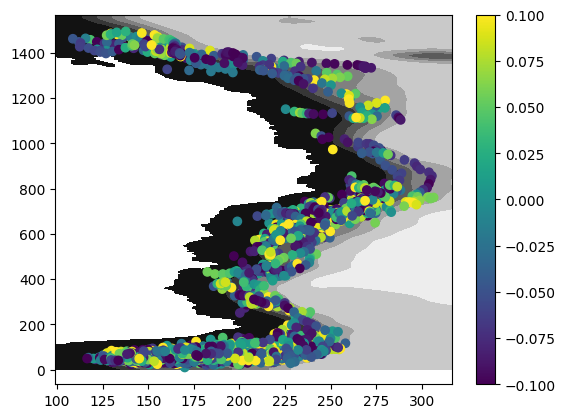

In [6]:

for eddy in df_eddies_shelf.Eddy.unique():
    df = df_eddies_shelf[df_eddies_shelf.Eddy==eddy]
    plt.scatter(df.xc, df.yc, c=df.TiltDis)
plt.colorbar()
xlim = plt.xlim()
ylim = plt.ylim()
plt.contourf(X_grid, Y_grid, np.where(mask_rho, h, np.nan), cmap='grey', zorder=0)
plt.xlim(xlim); plt.ylim(ylim)
# plt.axis('equal')


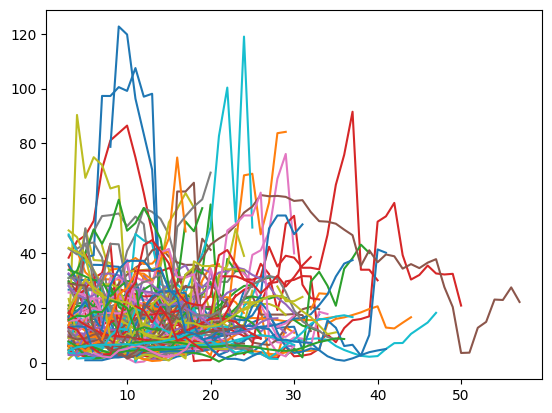

In [7]:
for eddy in df_eddies_shelf.Eddy.unique():
    df = df_eddies_shelf[df_eddies_shelf.Eddy==eddy]
    plt.plot(df.Day-df.Day.iloc[0], df.TiltDis)
    

In [8]:
def plot_single_eddy_tilt(
    eddy, df_eddies,
    X_grid, Y_grid, h, mask_rho,
    gap=5, s=5, figsize=(7, 7),
    tilt_dir_offset=-20,
    ax=None,
    cbar=False,
    color=None
):
    def point_b(a, r, theta_deg):
        theta_rad = np.radians(theta_deg)
        dx = r * np.sin(theta_rad)
        dy = r * np.cos(theta_rad)
        return a[0] - dx, a[1] - dy

    def darken(color, factor=0.7):
        r, g, b = to_rgb(color)
        return (r * factor, g * factor, b * factor)

    df_eddy = df_eddies.loc[df_eddies.Eddy.eq(eddy)].sort_values('Day').copy()

    if len(df_eddy) == 0:
        raise ValueError(f'Eddy {eddy} not found')

    cyc = df_eddy.Cyc.iloc[0]
    if color is None:
        color = 'c' if cyc == 'CE' else 'r'

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    else:
        fig = ax.figure

    m = ax.contourf(
        X_grid, Y_grid,
        np.where(mask_rho, h / 1e3, np.nan),
        cmap='gray'
    )

    ax.plot(df_eddy.xc, df_eddy.yc, color=color, linewidth=0.5, zorder=1)

    for d, data in df_eddy.iterrows():

        x0, y0 = data.xc, data.yc
        tilt_dis = data.TiltDis
        tilt_dir = data.TiltDir

        if np.isnan(tilt_dis) or np.isnan(tilt_dir):
            ax.scatter(
                x0, y0,
                edgecolors=darken(color, 0.8),
                facecolors='none',
                s=15,
                zorder=3
            )
            continue

        xb, yb = point_b(
            [x0, y0],
            tilt_dis,
            (tilt_dir + tilt_dir_offset) % 360
        )

        ax.plot([x0, xb], [y0, yb], color=color, zorder=2)
        ax.scatter(x0, y0, color=darken(color, 0.8), s=s, zorder=3)

    ax.text(
        df_eddy.iloc[0].xc + 15,
        df_eddy.iloc[0].yc + 15,
        'A',
        color='r',
        fontsize=14
    )

    ax.set_title(f'{cyc}{eddy}')
    ax.set_xlabel('x (km)')
    ax.set_ylabel('y (km)')
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(df_eddy.xc.min() - gap, df_eddy.xc.max() + gap)
    ax.set_ylim(df_eddy.yc.min() - gap, df_eddy.yc.max() + gap)

    if cbar:
        cb = fig.colorbar(m, ax=ax, location='top', shrink=0.7)
        cb.set_label('Bathymetry [km]')

    return fig, ax, m
    

In [9]:
valid_eddies = (
    df_eddies_shelf
    .groupby('Eddy')['TiltDis']
    .apply(lambda x: (x.isna().sum() == 6) and (x.notna().sum() >= 7))
)

eddies = valid_eddies[valid_eddies].index
len(eddies)


55

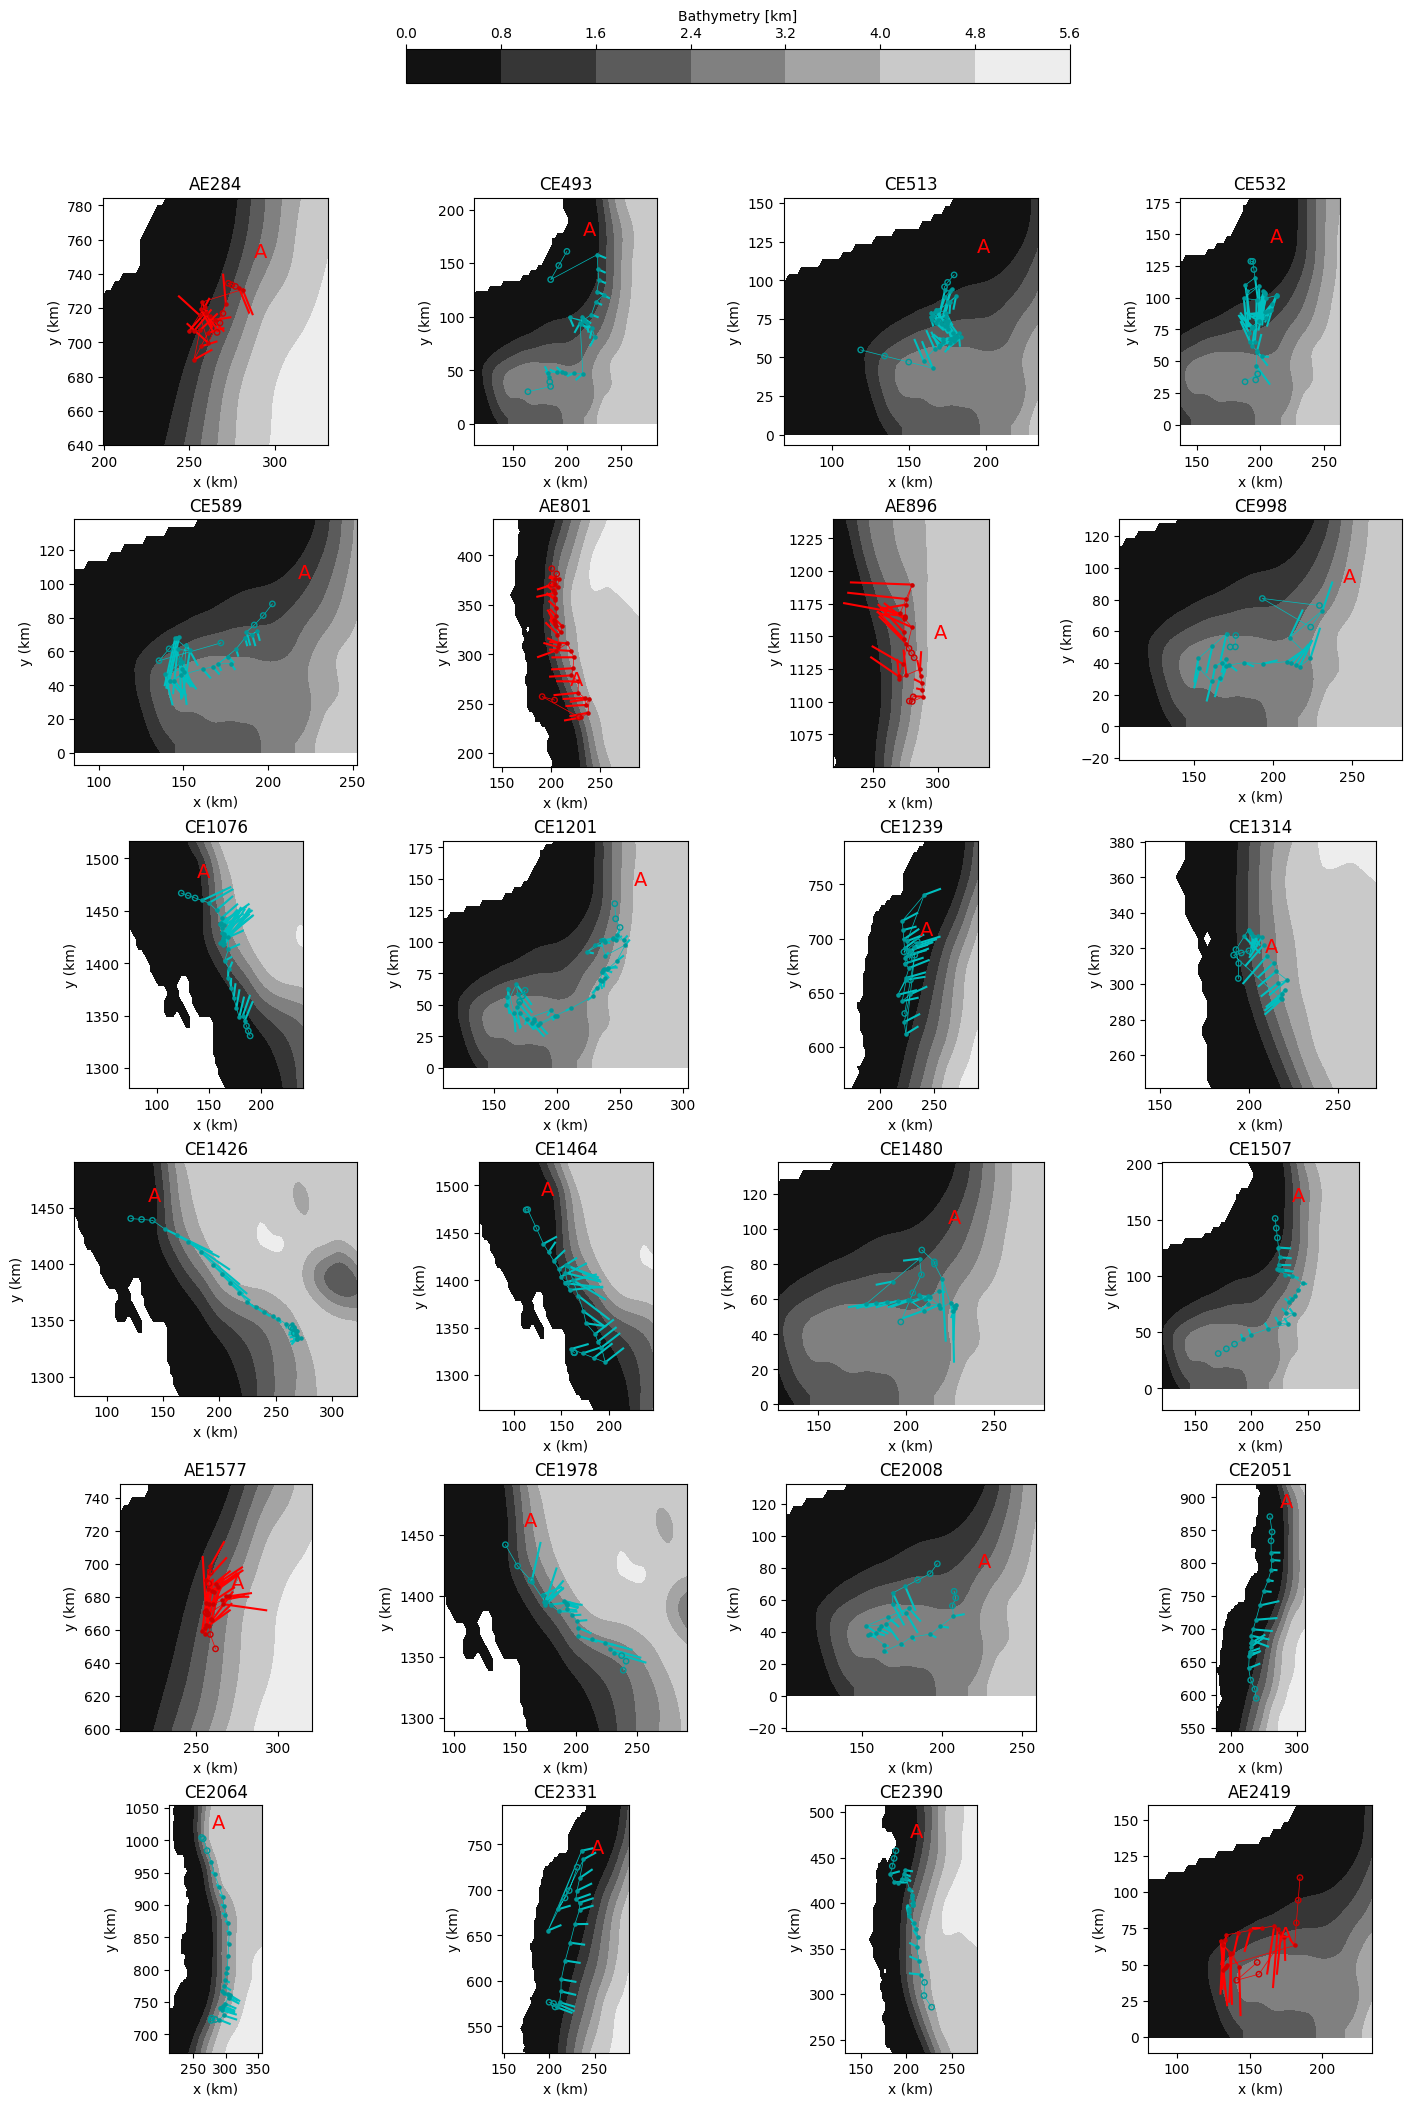

In [10]:
fig, axs = plt.subplots(6, 4, figsize=(14, 21), constrained_layout=True)

axs = axs.ravel()

m = None
for ax, eddy in zip(axs, eddies):
    fig, ax, m = plot_single_eddy_tilt(
        eddy, df_eddies,
        X_grid, Y_grid, h, mask_rho,
        gap=50,
        ax=ax
    )

cbar = fig.colorbar(m, ax=axs, location='top', shrink=0.5)
cbar.set_label('Bathymetry [km]')


Text(0.5, 0, 'Tilt bearing - slope bearing [deg]')

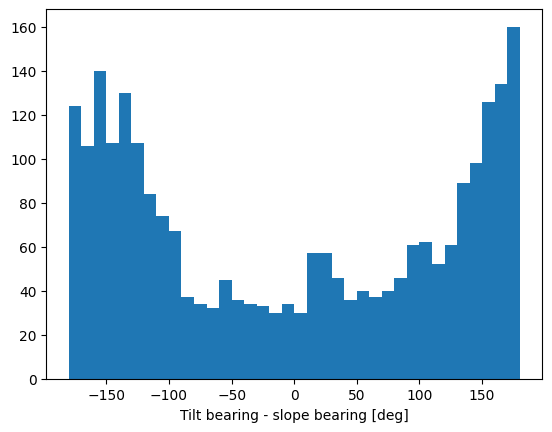

In [12]:
# dhdy, dhdx = np.gradient(h, X_grid[:,0], Y_grid[0,:])

# gx = dhdx[df_eddies.ic, df_eddies.jc]   # east component
# gy = dhdy[df_eddies.ic, df_eddies.jc]   # north component

# df_eddies['slope_bearing'] = (90 - np.degrees(np.arctan2(gx, gy)) + 20) % 360

# df_eddies['theta'] = ((df_eddies.TiltDir - df_eddies.slope_bearing + 180) % 360) - 180

# df_eddies_shelf = df_eddies[df_eddies.Eddy.isin(df_eddies_shelf.Eddy.unique())].copy()

# plt.hist(df_eddies_shelf.theta, bins=np.arange(-180, 181, 10))
# plt.xlabel('Tilt bearing - slope bearing [deg]')

# rounded version
dhdy, dhdx = np.gradient(h, X_grid[:,0], Y_grid[0,:])

df_eddies_shelf = compute_core_mean( # mean value
    df_eddies_shelf,
    X_grid, Y_grid,
    mask_rho,
    fixed_field=dhdx,
    colname="gx"
)

df_eddies_shelf = compute_core_mean( # mean value
    df_eddies_shelf,
    X_grid, Y_grid,
    mask_rho,
    fixed_field=dhdy,
    colname="gy"
)

df_eddies_shelf['slope_bearing'] = (90 - np.degrees(np.arctan2(df_eddies_shelf.gx, df_eddies_shelf.gy)) + 20) % 360

df_eddies_shelf['theta'] = ((df_eddies_shelf.TiltDir - df_eddies_shelf.slope_bearing + 180) % 360) - 180

df_eddies_shelf = df_eddies_shelf[df_eddies_shelf.Eddy.isin(df_eddies_shelf.Eddy.unique())].copy()

plt.hist(df_eddies_shelf.theta, bins=np.arange(-180, 181, 10))
plt.xlabel('Tilt bearing - slope bearing [deg]')



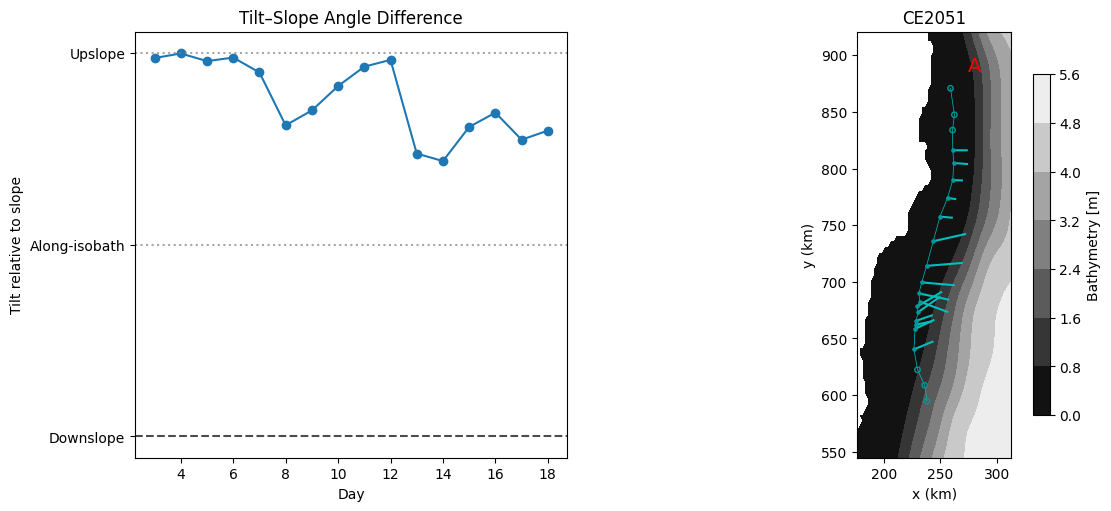

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)

eddy = 2051

# Left panel: theta time series
df = df_eddies_shelf[df_eddies_shelf.Eddy == eddy].copy()

axs[0].plot(df.Day - df.Day.iloc[0], df.theta.abs(), '-o')

axs[0].axhline(0, color='k', ls='--', alpha=0.7)
axs[0].axhline(90, color='grey', ls=':', alpha=0.7)
# axs[0].axhline(-90, color='grey', ls=':', alpha=0.7)
axs[0].axhline(180, color='grey', ls=':', alpha=0.7)
# axs[0].axhline(-180, color='grey', ls=':', alpha=0.7)

axs[0].set_yticks(
    [0, 90, 180],
    ['Downslope', 'Along-isobath', 'Upslope']
)

axs[0].set_xlabel('Day')
axs[0].set_ylabel('Tilt relative to slope')
axs[0].set_ylim(-10, 190)
axs[0].set_title('Tilt–Slope Angle Difference')

# Right panel: eddy map
fig, ax_map, m = plot_single_eddy_tilt(
    eddy, df_eddies_shelf,
    X_grid, Y_grid, h, mask_rho,
    gap=50,
    ax=axs[1],
    color='c'
)

cbar = fig.colorbar(m, ax=axs[1], shrink=0.8)
cbar.set_label('Bathymetry [m]')


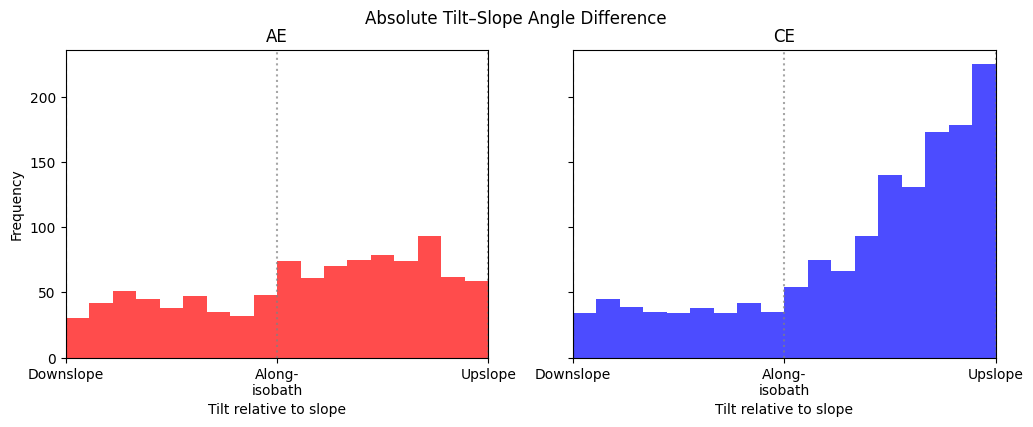

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

bins = np.arange(0, 181, 10)

for ax, cyc, clr in zip(axs, ['AE', 'CE'], ['r', 'b']):

    theta = np.abs(
        df_eddies_shelf.loc[
            df_eddies_shelf.Cyc == cyc,
            'theta'
        ].dropna()
    )

    ax.hist(theta, bins=bins, color=clr, alpha=0.7)

    ax.axvline(0, color='k', ls='--', alpha=0.7)
    ax.axvline(90, color='grey', ls=':', alpha=0.7)
    ax.axvline(180, color='grey', ls=':', alpha=0.7)

    ax.set_xticks([0, 90, 180])
    ax.set_xticklabels([
        'Downslope',
        'Along-\nisobath',
        'Upslope'
    ])

    ax.set_xlim(0, 180)
    ax.set_title(cyc)

axs[0].set_ylabel('Frequency')
axs[0].set_xlabel('Tilt relative to slope')
axs[1].set_xlabel('Tilt relative to slope')

fig.suptitle('Absolute Tilt–Slope Angle Difference')
plt.show()
